In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

In [2]:
mg = {
    'Name': ["Peter", "Quagmire", "Luois", "Stewie", "Brian", "Griffins", "Giant Dog", "Meg", "Obama", "Chris", "Leg", "Putin"],
    'NET': [51, 63, 59, 45, 85, 74, 95, 96, 23, 65, 22.2, 14],
    'Dev': [45, 52, 23, 14, 25, 63, 9, 74, 50, 63.2, 66, 12],
    'WeD': [36, 25, 5, 62, 19, 18, 55, 65, 44, 70, 69, 33.6],
    'PWD': [52, 66, 23, 12, 21, 41, 52, 25, 36, 45.6, 77, 63],
    'JSC': [25, 14, 52, 63, 45, 21, 85, 96, 45, 63, 55.3, 23],
    'DVS': [75, 85, 96, 5, 45, 63, 47, 65, 23.6, 52, 60, 50],
    'EVS': [30, 66, 56, 45, 32.3, 44, 51, 25, 36, 47, 58, 56]
}

gh = pd.DataFrame(mg)
gh

,Name,NET,Dev,WeD,PWD,JSC,DVS,EVS
0,Peter,51.0,45.0,36.0,52.0,25.0,75.0,30.0
1,Quagmire,63.0,52.0,25.0,66.0,14.0,85.0,66.0
2,Luois,59.0,23.0,5.0,23.0,52.0,96.0,56.0
3,Stewie,45.0,14.0,62.0,12.0,63.0,5.0,45.0
4,Brian,85.0,25.0,19.0,21.0,45.0,45.0,32.3
5,Griffins,74.0,63.0,18.0,41.0,21.0,63.0,44.0
6,Giant Dog,95.0,9.0,55.0,52.0,85.0,47.0,51.0
7,Meg,96.0,74.0,65.0,25.0,96.0,65.0,25.0
8,Obama,23.0,50.0,44.0,36.0,45.0,23.6,36.0
9,Chris,65.0,63.2,70.0,45.6,63.0,52.0,47.0


## **Bar Charts**

<Axes: title={'center': 'NET Scores'}, xlabel='Name'>

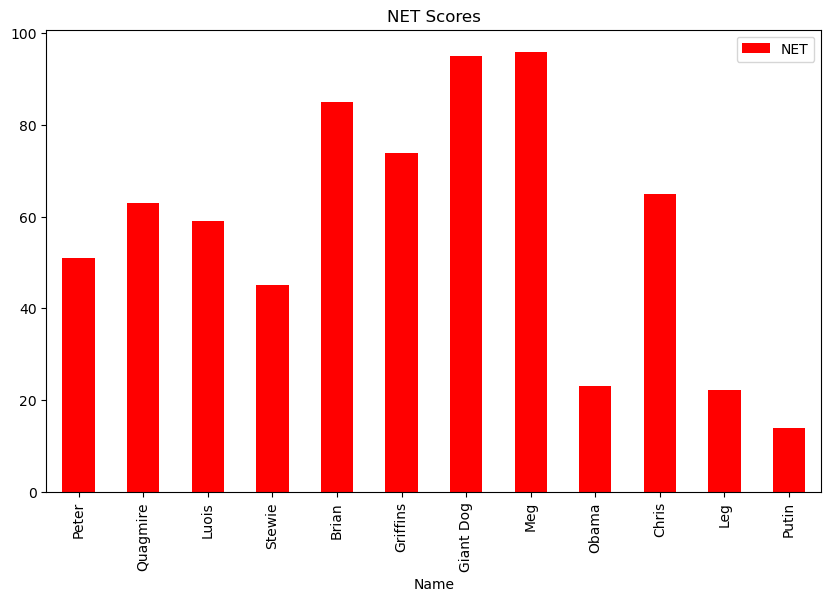

In [5]:
# 1. Bar: NET scores
gh.plot.bar(x='Name', y='NET', title='NET Scores',color='r', figsize=(10, 6))

<Axes: ylabel='Name'>

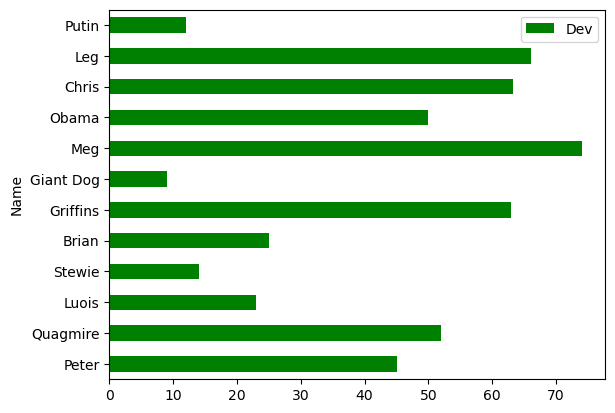

In [6]:
# 2. Horizontal bar: Dev
gh.plot.barh(x='Name', y='Dev', color='g')

<Axes: >

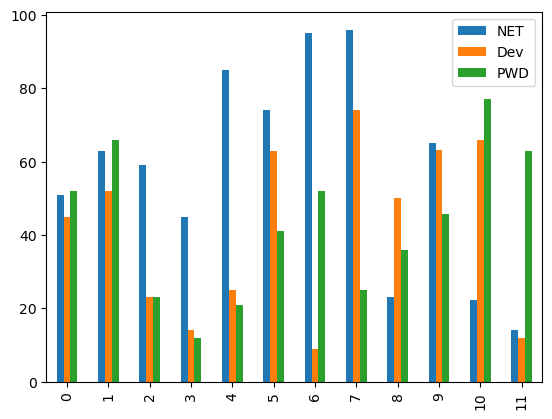

In [7]:
# 3. Multiple bars
gh[['NET', 'Dev', 'PWD']].plot.bar()

<Axes: >

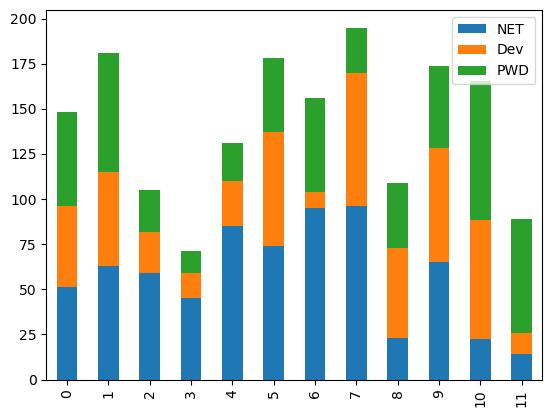

In [8]:
# 4. Stacked bar
gh[['NET', 'Dev', 'PWD']].plot.bar(stacked=True)

<Axes: xlabel='Name'>

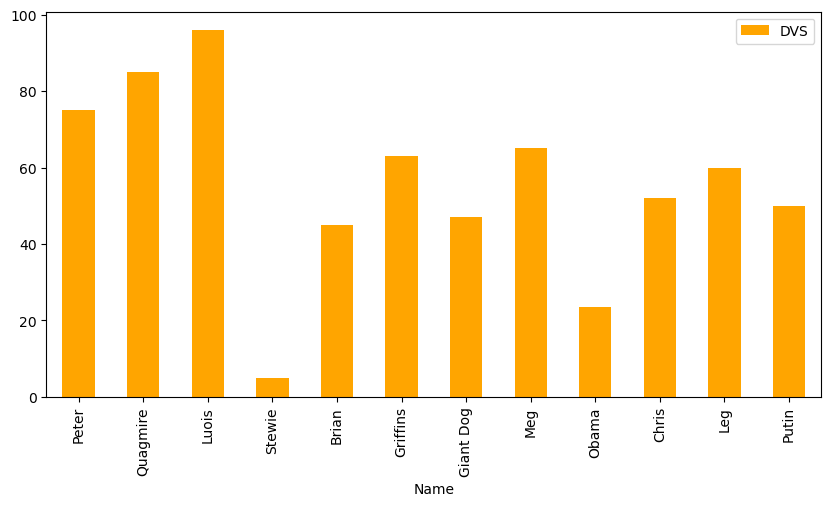

In [9]:
# 5. Customized bar
gh.plot.bar(x='Name', y='DVS', color='orange', figsize=(10,5))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Peter'),
  Text(1, 0, 'Quagmire'),
  Text(2, 0, 'Luois'),
  Text(3, 0, 'Stewie'),
  Text(4, 0, 'Brian'),
  Text(5, 0, 'Griffins'),
  Text(6, 0, 'Giant Dog'),
  Text(7, 0, 'Meg'),
  Text(8, 0, 'Obama'),
  Text(9, 0, 'Chris'),
  Text(10, 0, 'Leg'),
  Text(11, 0, 'Putin')])

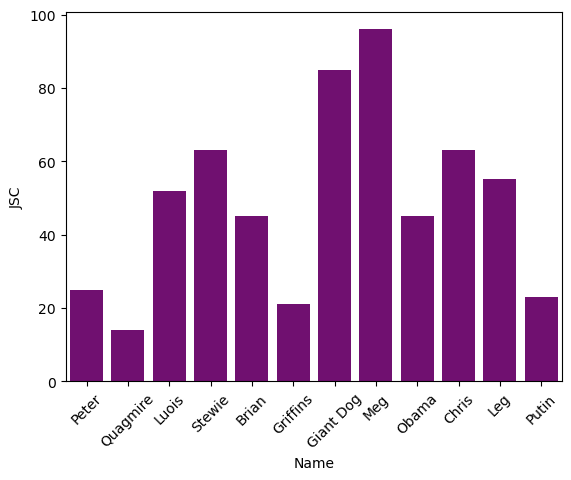

In [11]:
# 6. Seaborn barplot
sns.barplot(x='Name', y='JSC', data=gh,color='purple', ci=None)
plt.xticks(rotation=45)

<Axes: xlabel='Result', ylabel='NET'>

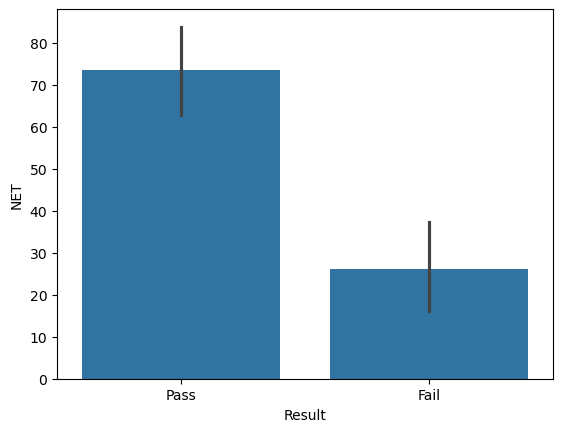

In [12]:
# 7. Barplot with hue
gh['Result'] = ['Pass' if x > 50 else 'Fail' for x in gh['NET']]
sns.barplot(x='Result', y='NET', data=gh)

<Axes: xlabel='Name'>

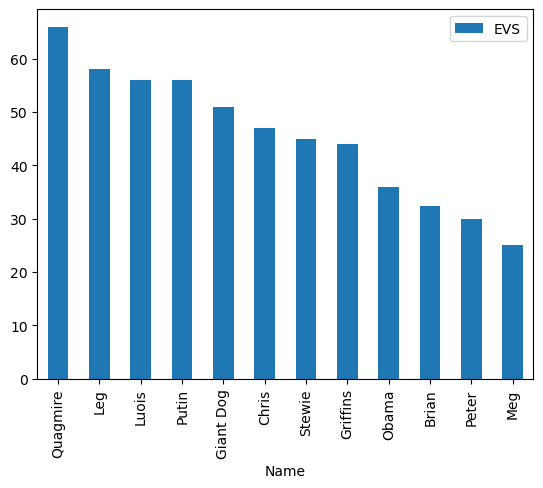

In [13]:
# 8. Sorted barplot
gh.sort_values('EVS', ascending=False).plot.bar(x='Name', y='EVS')

<Axes: xlabel='Result'>

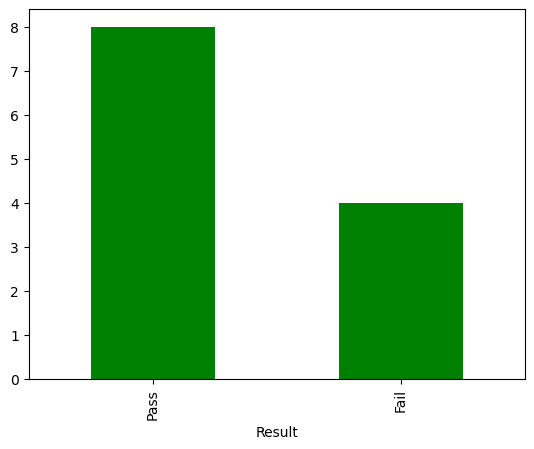

In [14]:
# 9. Value counts bar
gh['Result'].value_counts().plot(kind='bar', color='green')

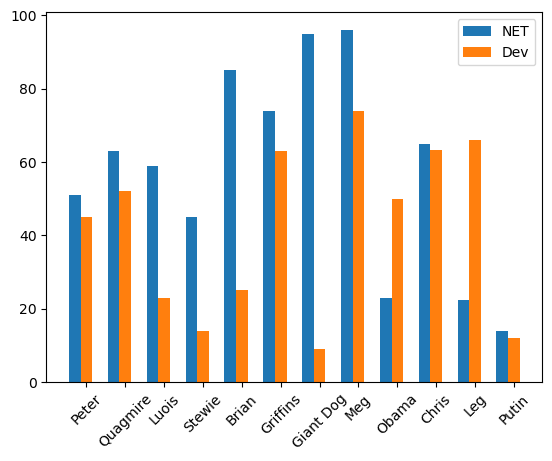

In [15]:
# 10. Grouped bar chart (manual)
width = 0.3
x = np.arange(len(gh))
plt.bar(x - width, gh['NET'], width=width, label='NET')
plt.bar(x, gh['Dev'], width=width, label='Dev')
plt.xticks(x, gh['Name'], rotation=45)
plt.legend()

## **Line Plots**

<Axes: xlabel='Name'>

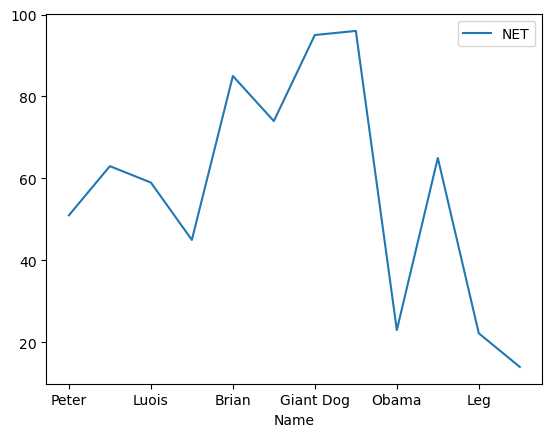

In [16]:
# 11. Simple line
gh.plot.line(x='Name', y='NET')

<Axes: xlabel='Name'>

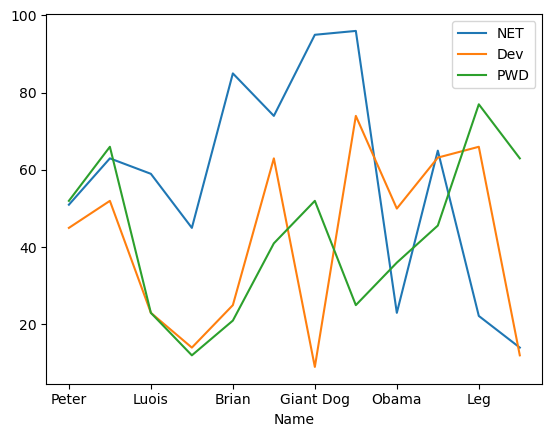

In [17]:
# 12. Line for multiple subjects
gh.set_index('Name')[['NET', 'Dev', 'PWD']].plot()

<Axes: xlabel='Name'>

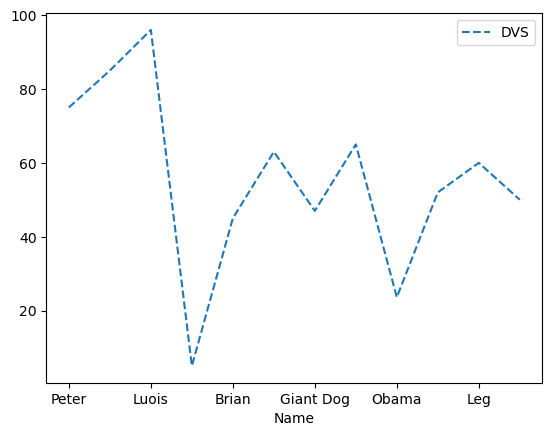

In [18]:
# 13. Dashed line
gh.plot.line(x='Name', y='DVS', linestyle='--')

<Axes: xlabel='Name'>

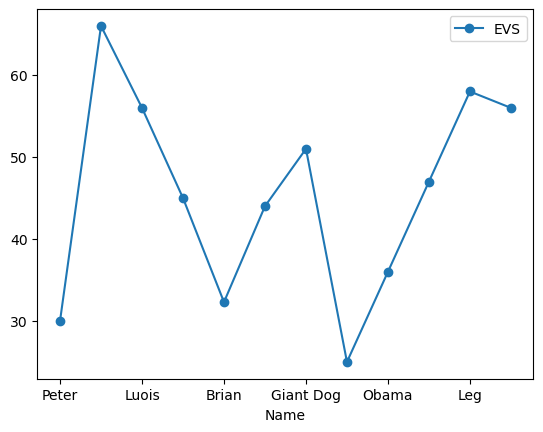

In [19]:
# 14. Line with markers
gh.plot.line(x='Name', y='EVS', marker='o')

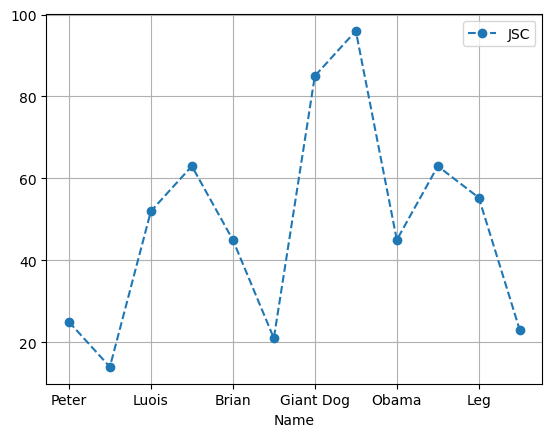

In [20]:
# 15. Line with grid
gh.plot(x='Name', y='JSC', style='--o')
plt.grid(True)


<Axes: xlabel='Name'>

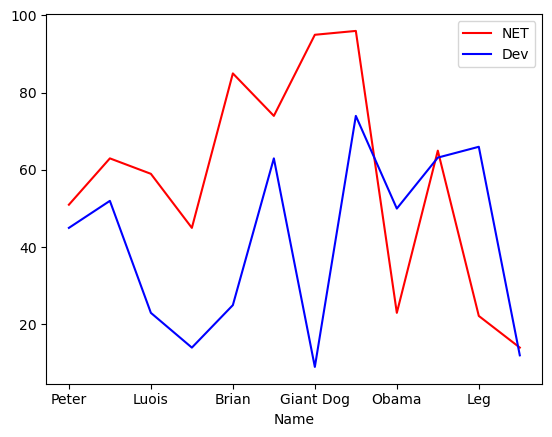

In [21]:
# 16. Color-coded lines
gh.set_index('Name')[['NET', 'Dev']].plot(color=['r', 'b'])

array([[<Axes: >],
       [<Axes: >],
       [<Axes: >]], dtype=object)

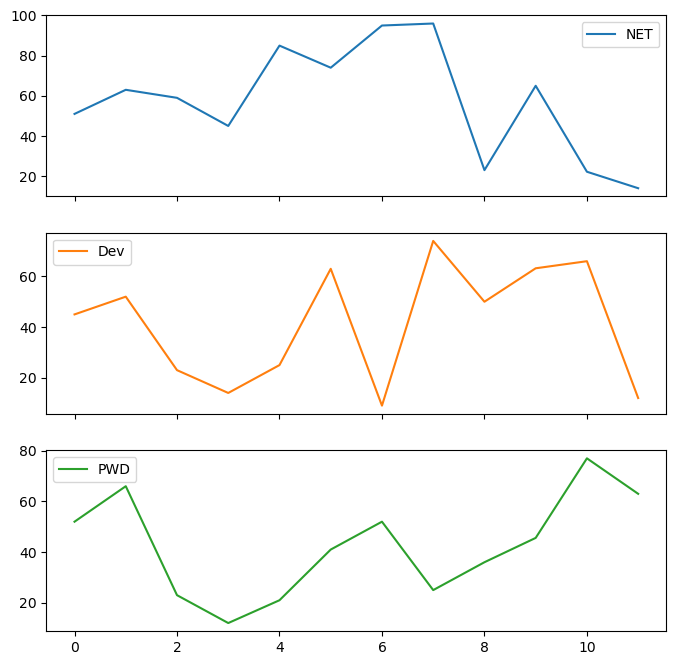

In [22]:
# 17. Multiple line charts in subplots
gh[['NET', 'Dev', 'PWD']].plot(subplots=True, layout=(3,1), figsize=(8, 8))


<Axes: title={'center': 'Rolling Average NET'}>

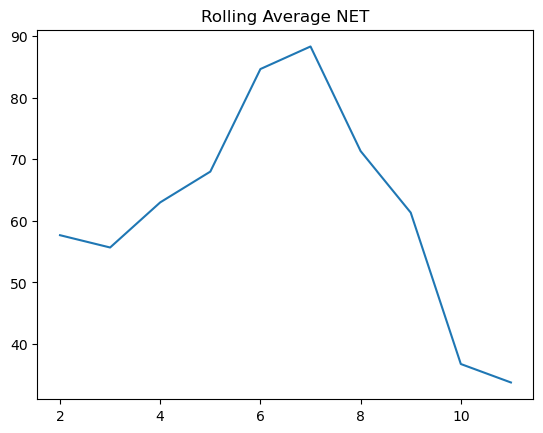

In [23]:
# 18. Smoothed line (rolling avg)
gh['NET'].rolling(3).mean().plot(title='Rolling Average NET')

(0.0, 100.0)

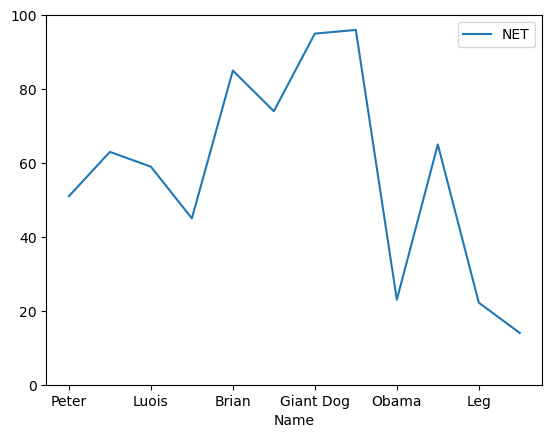

In [24]:
# 19. Line with limits
gh.plot(x='Name', y='NET')
plt.ylim(0, 100)

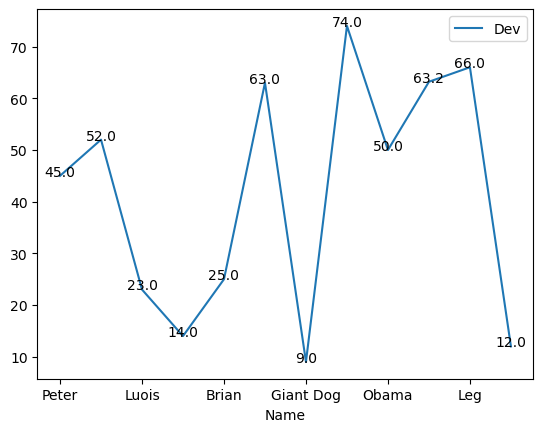

In [25]:
# 20. Line plot with annotations
ax = gh.plot(x='Name', y='Dev')
for i in range(len(gh)):
    ax.text(i, gh['Dev'][i], round(gh['Dev'][i],1), ha='center')

## **Pie Charts**

<Axes: ylabel='count'>

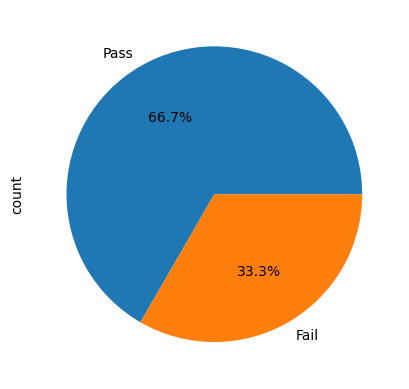

In [26]:
# 21. Pie of Result
gh['Result'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='EVS'>

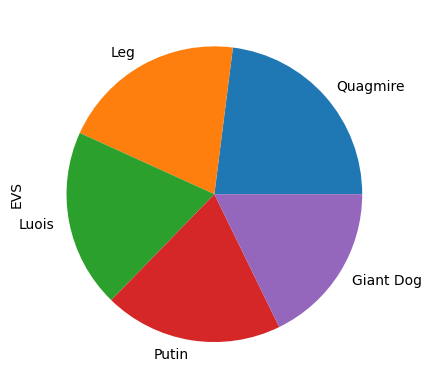

In [27]:
# 22. Pie of top 5 EVS
gh.nlargest(5, 'EVS').set_index('Name')['EVS'].plot.pie()

([<matplotlib.patches.Wedge at 0x1d886e88c50>,
 [Text(0.5785361715602308, 1.051330537079767, 'Peter'),
  Text(-1.033661855467694, -0.37622223293033136, 'Quagmire'),
  Text(0.626300414073604, -0.9042940845384494, 'Luois'),
  Text(1.066776664979647, -0.2683049516033989, 'Stewie')],
 [Text(0.33747943341013464, 0.6132761466298641, '34.0%'),
  Text(-0.563815557527833, -0.20521212705290798, '43.1%'),
  Text(0.34161840767651125, -0.4932513188391542, '15.0%'),
  Text(0.5818781808979893, -0.14634815542003574, '7.8%')])

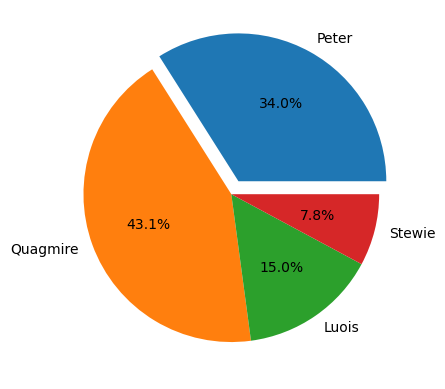

In [28]:
# 23. Pie with labels & explode
plt.pie(gh['PWD'][:4], labels=gh['Name'][:4], explode=[0.1,0,0,0], autopct='%1.1f%%')

<Axes: ylabel='NET'>

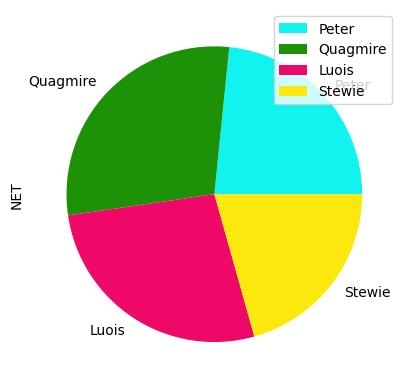

In [32]:
# 24. Pie with custom colors
gh[:4].plot.pie(y='NET', labels=gh['Name'][:4], colors=["#11f3ef","#1d9206","#ee0969","#fce80c"])

array([<Axes: ylabel='NET'>, <Axes: ylabel='Dev'>, <Axes: ylabel='PWD'>],
      dtype=object)

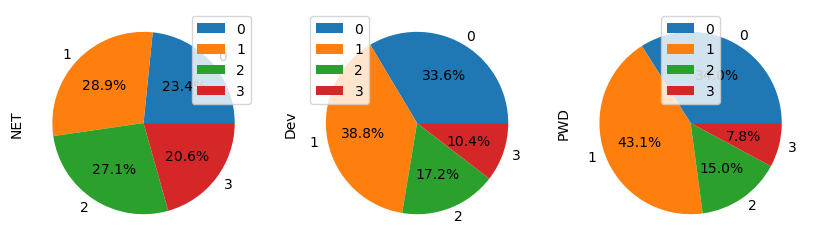

In [31]:
# 25. Pie as subplots
gh[['NET', 'Dev', 'PWD']][:4].plot.pie(subplots=True, autopct='%1.1f%%', figsize=(10,4))

## **Histograms & Distributions**

<Axes: ylabel='Frequency'>

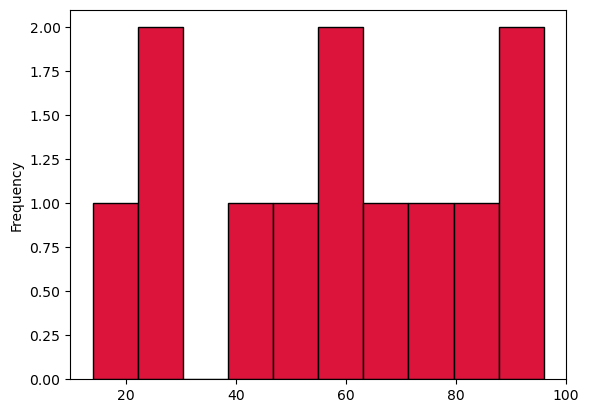

In [36]:
# 26. Histogram of NET
gh['NET'].plot.hist(bins=10,color='crimson', edgecolor='black')

<Axes: xlabel='JSC', ylabel='Count'>

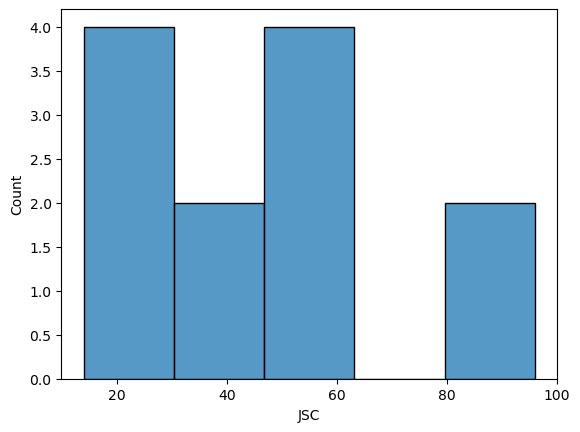

In [37]:
# 28. Histogram by Seaborn
sns.histplot(gh['JSC'], kde=False)

<Axes: xlabel='EVS', ylabel='Density'>

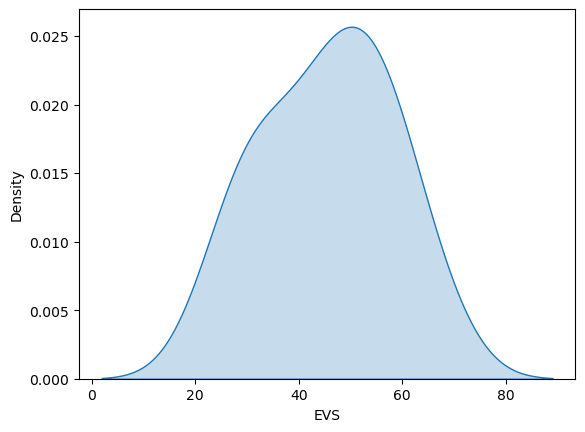

In [38]:
# 29. KDE Plot
sns.kdeplot(gh['EVS'], shade=True)

<Axes: xlabel='EVS', ylabel='Count'>

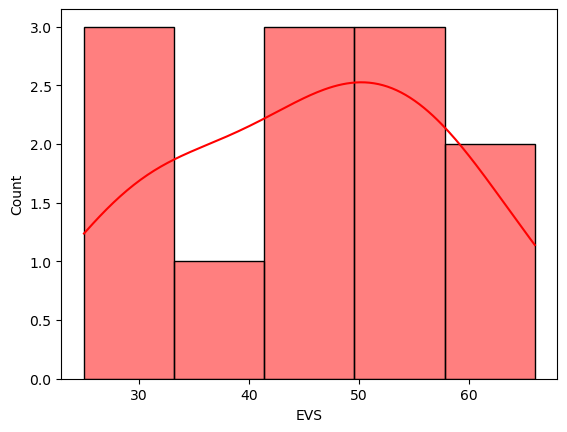

In [40]:
# 30. Histogram + KDE
sns.histplot(gh['EVS'], kde=True,color='r')

<Axes: ylabel='Frequency'>

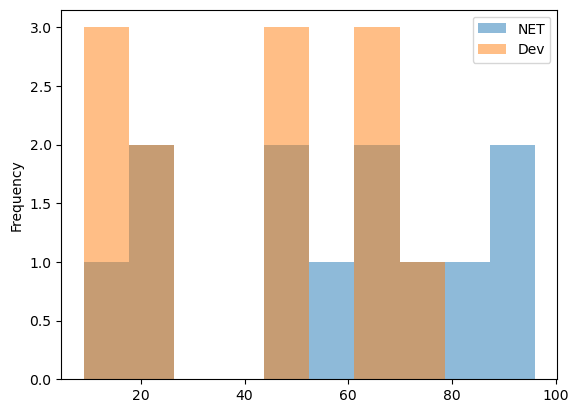

In [41]:
# 31. Multiple hist
gh[['NET', 'Dev']].plot.hist(alpha=0.5, bins=10)


<Axes: xlabel='EVS', ylabel='Density'>

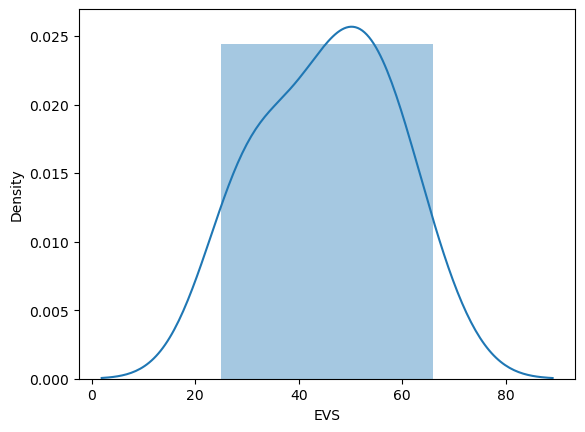

In [42]:
# 32. Seaborn distplot (deprecated)
sns.distplot(gh['EVS'])


<Axes: xlabel='Result', ylabel='count'>

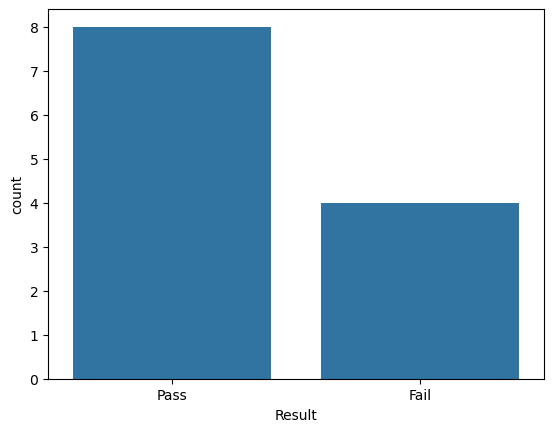

In [43]:
# 33. Countplot
sns.countplot(x='Result', data=gh)

<Axes: xlabel='Dev'>

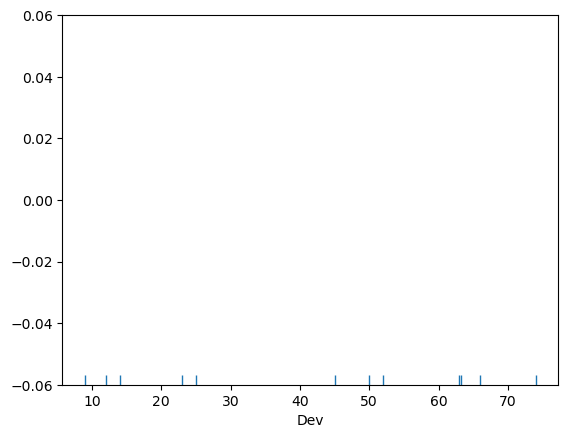

In [44]:
# 34. Rugplot
sns.rugplot(gh['Dev'])

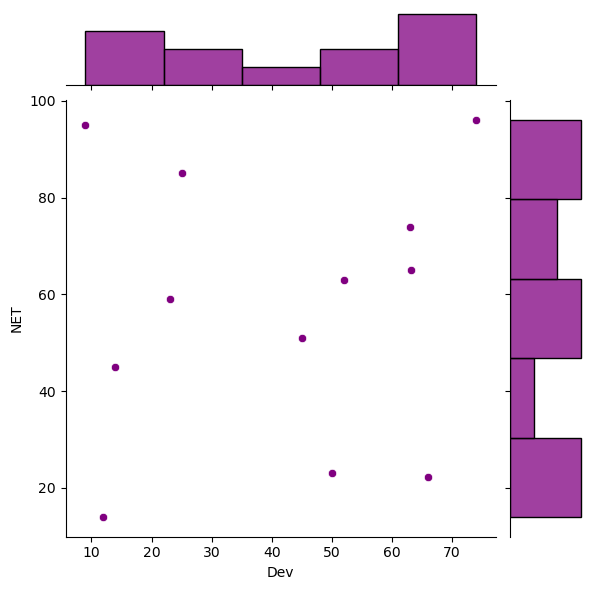

In [46]:
# 35. Jointplot
sns.jointplot(x='Dev', y='NET', data=gh,color='purple')

## **Boxplots & Violin Plots**

<Axes: >

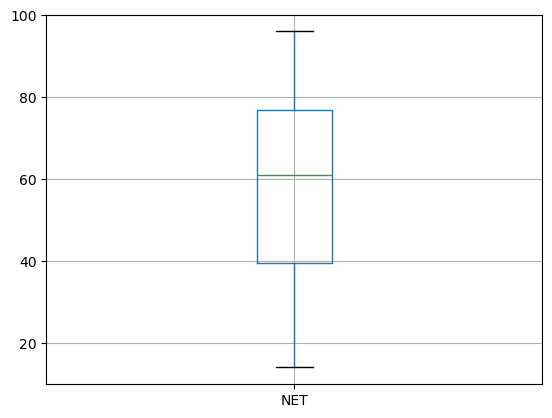

In [47]:
# 36. Boxplot of NET
gh.boxplot(column='NET')

<Axes: xlabel='Result', ylabel='NET'>

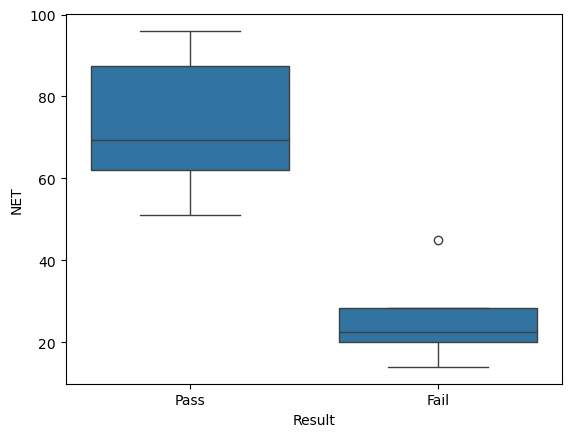

In [48]:
# 37. Boxplot by Result
sns.boxplot(x='Result', y='NET', data=gh)

<Axes: >

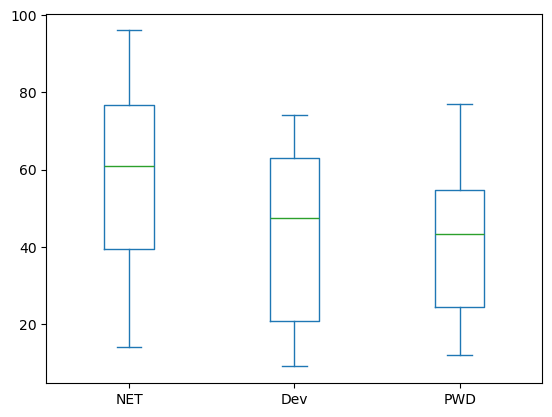

In [49]:
# 38. Multiple boxplots
gh[['NET', 'Dev', 'PWD']].plot.box()


<Axes: xlabel='Result', ylabel='Dev'>

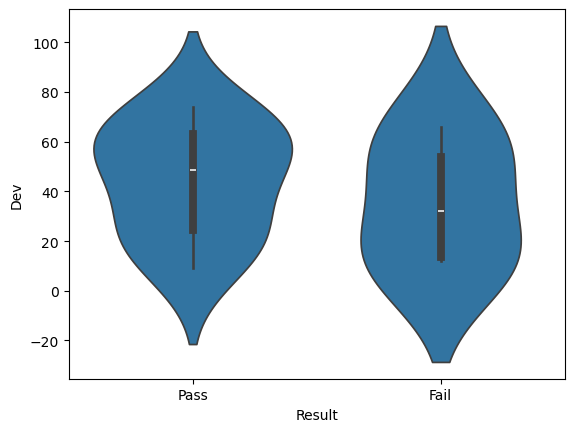

In [50]:
# 39. Violin plot
sns.violinplot(x='Result', y='Dev', data=gh)

<Axes: xlabel='Result', ylabel='PWD'>

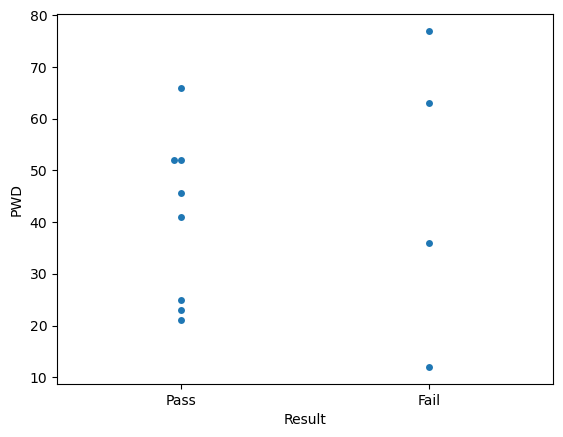

In [51]:
# 40. Swarm plot
sns.swarmplot(x='Result', y='PWD', data=gh)

## **Heatmaps & Correlation**

<Axes: >

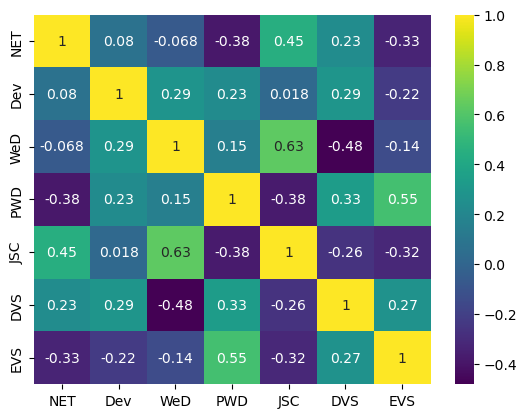

In [4]:
# 41. Correlation heatmap
sns.heatmap(gh.drop('Name', axis=1).corr(), annot=True, cmap='viridis')

<Axes: >

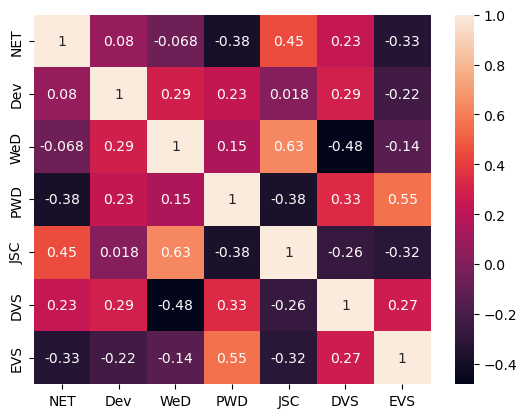

In [5]:
# 42. Annotated heatmap
sns.heatmap(gh.corr(numeric_only=True), annot=True)


Text(0.5, 1.0, 'Correlation Heatmap with Upper Triangle Masked')

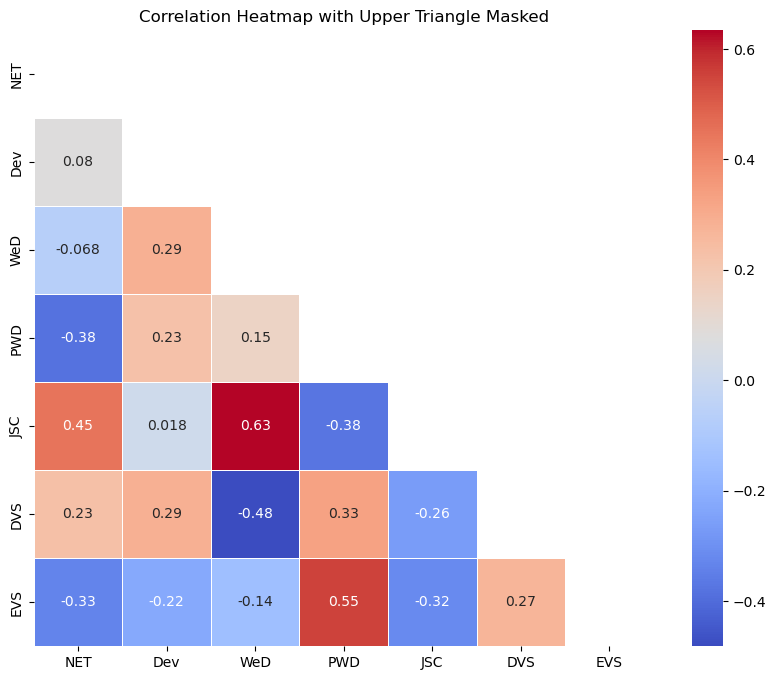

In [ ]:
corr_matrix = gh.corr(numeric_only=True)  # Ensures only numeric columns are used
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Create mask for upper triangle
plt.figure(figsize=(10, 8))  # Optional: adjust the figure size
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap with Upper Triangle Masked")

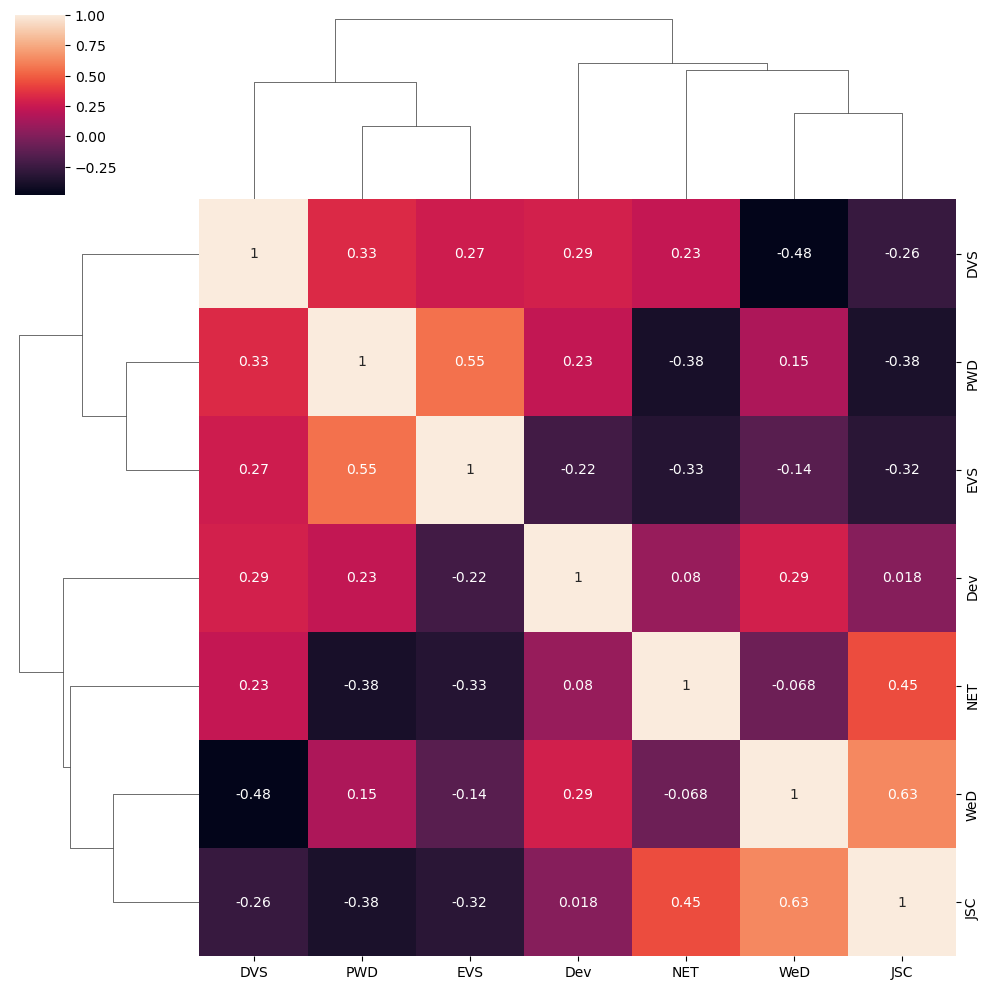

In [6]:
# 44. Cluster map
sns.clustermap(gh.drop('Name', axis=1).corr(), annot=True)

<Axes: >

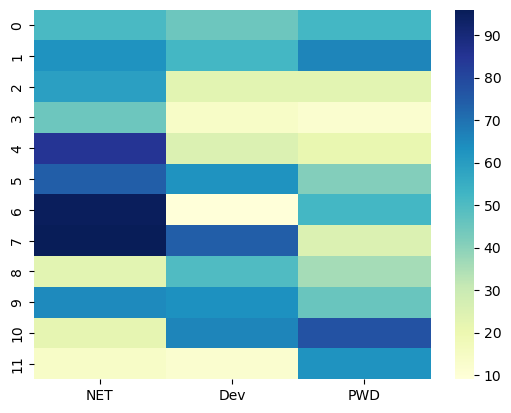

In [7]:
# 45. Color-coded dataframe values
sns.heatmap(gh[['NET', 'Dev', 'PWD']], cmap='YlGnBu')

## **Advanced or Fun**

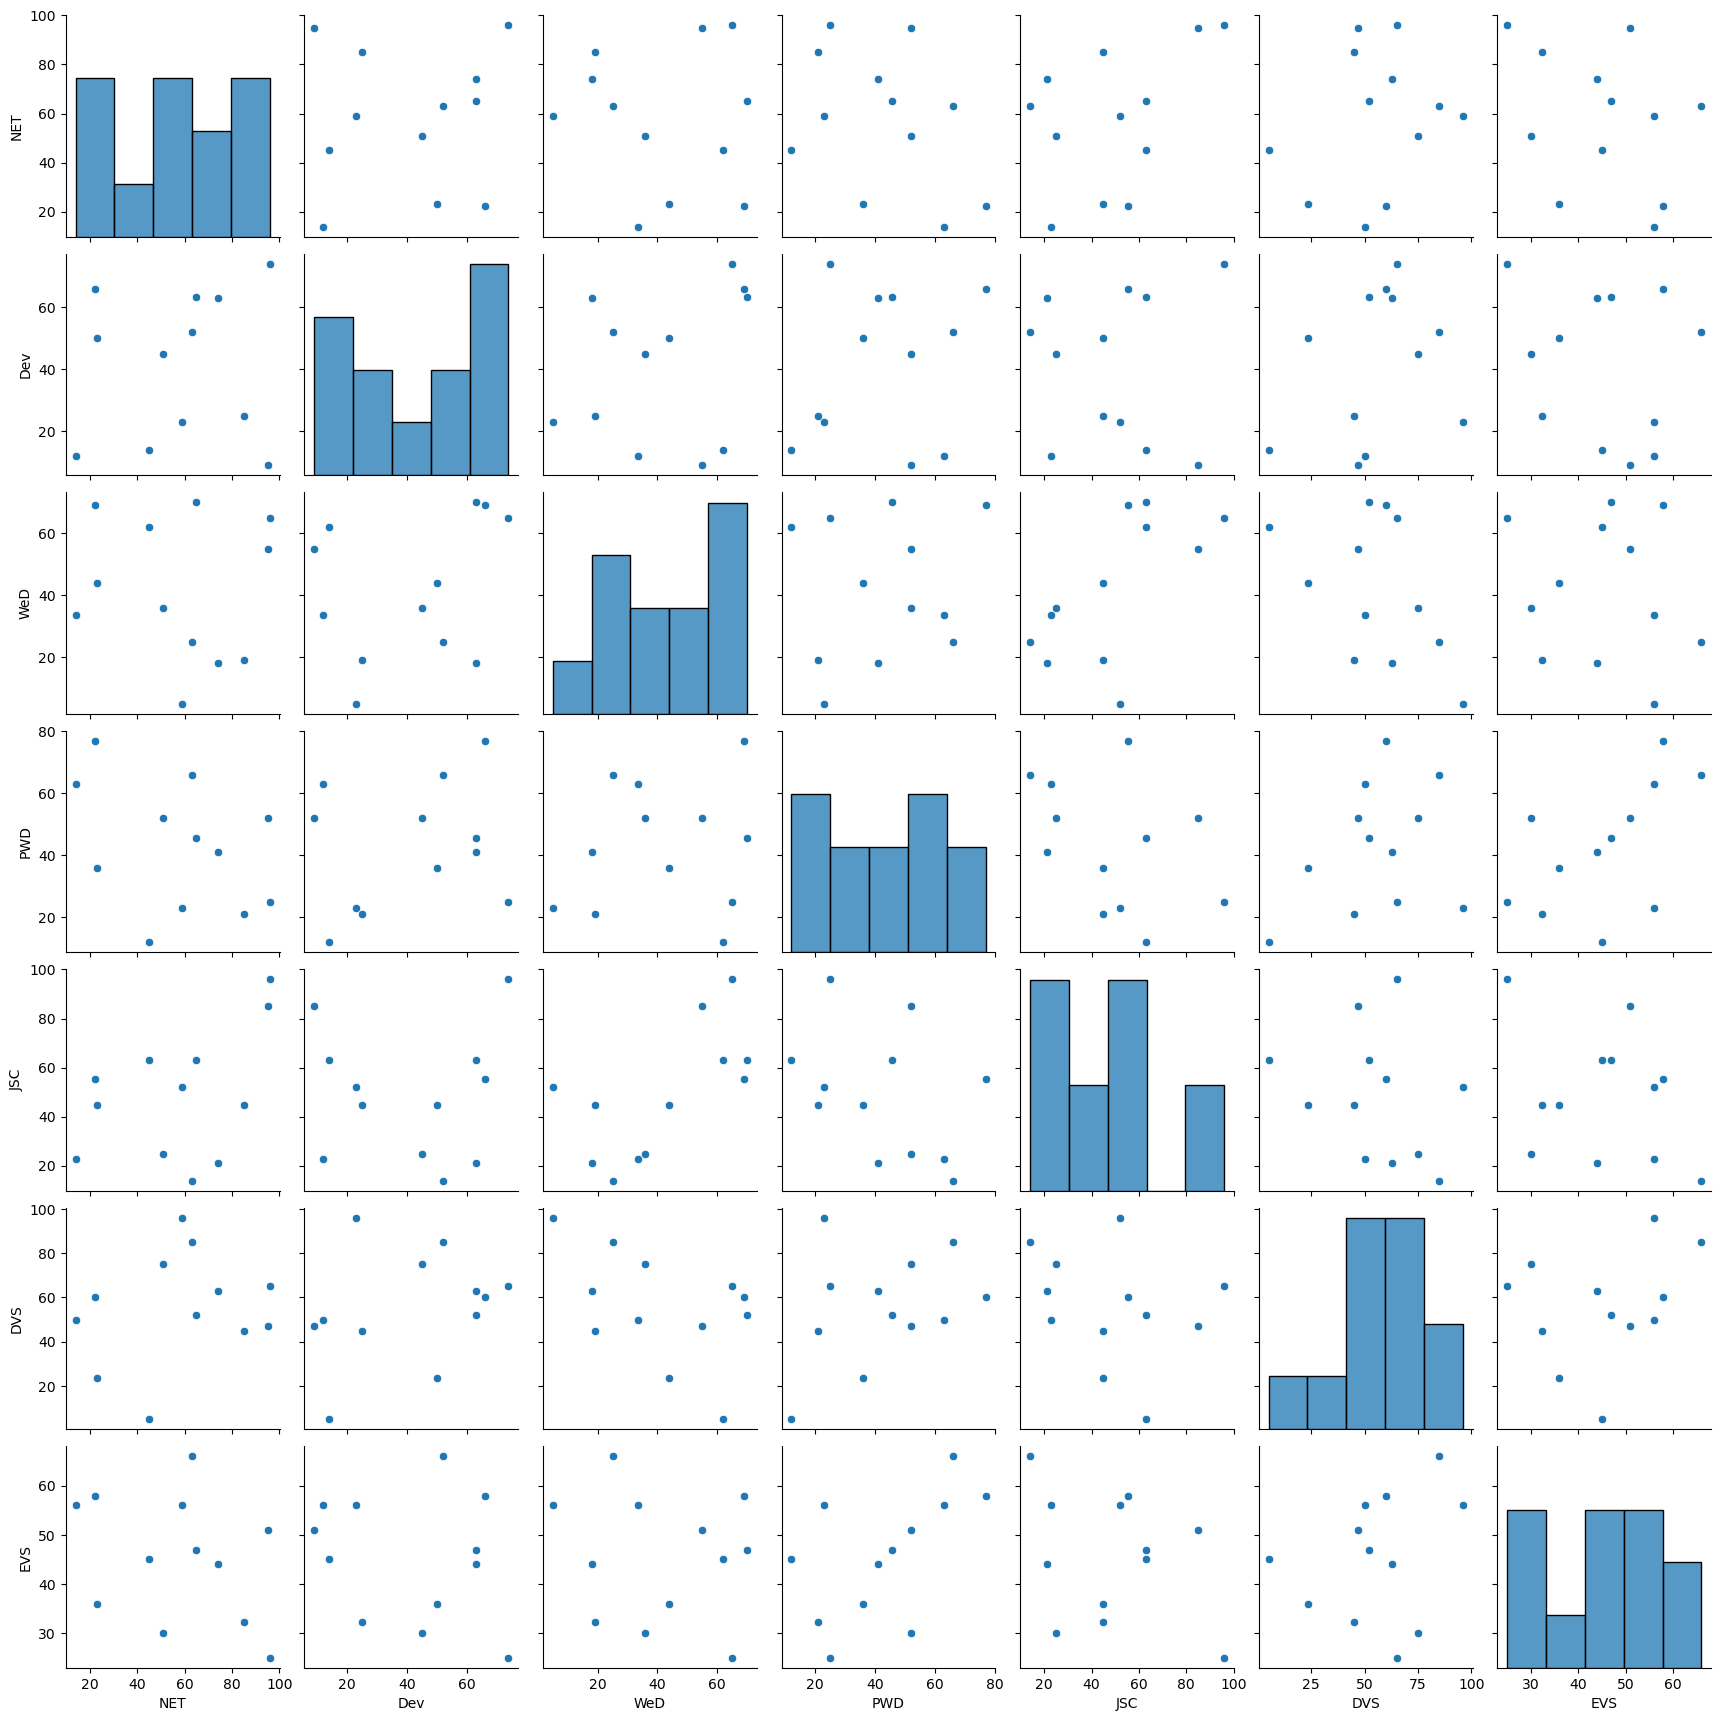

In [11]:
# 46. Pairplot
sns.pairplot(gh.drop('Name', axis=1))

Text(0, 0.5, 'Dev')

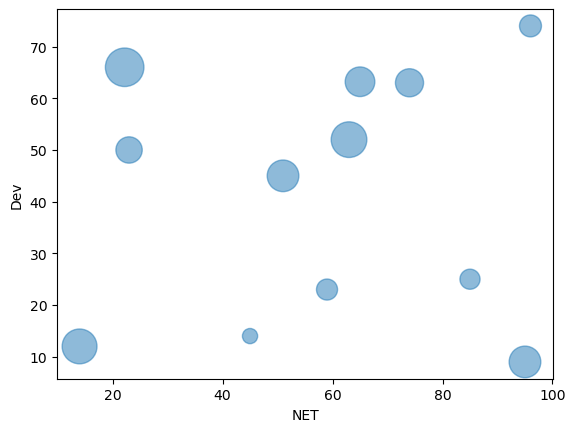

In [15]:
# 47. Bubble chart
plt.scatter(gh['NET'], gh['Dev'], s=gh['PWD']*10, alpha=0.5)
plt.xlabel("NET")
plt.ylabel("Dev")

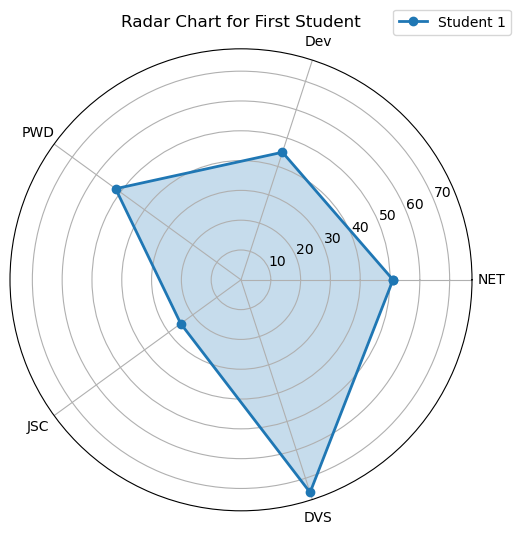

In [6]:
# Define the labels (must match the columns in your DataFrame)
labels = ['NET', 'Dev', 'PWD', 'JSC', 'DVS']

# Get the first row's values for those labels
values = gh.loc[0, labels].values.astype(float).tolist()

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()

# Close the loop
values += values[:1]
angles += angles[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, 'o-', linewidth=2, label='Student 1')
ax.fill(angles, values, alpha=0.25)

# Fix labels
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# Optional: Set title and legend
ax.set_title("Radar Chart for First Student")
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

<Axes: >

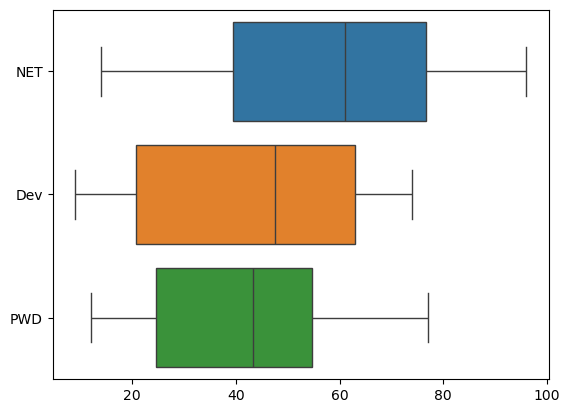

In [7]:
# 50. Horizontal boxplot
sns.boxplot(data=gh[['NET', 'Dev', 'PWD']], orient='h')